# IndiaKart E-Commerce Analytics Project
## Phase 2 — Exploratory Data Analysis

**Name:** Kartik Jaswal

### Objective
The objective of this phase is to analyze customer, order, payment, product, and return data using Python. The analysis focuses on monthly sales trends, customer segments, payment behaviour, product categories, order status, geographic performance, customer demographics, and return patterns.

A total of 10 visualizations will be created and each chart will include key business observations.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [45]:
base_path = r"C:\Users\karti\Desktop\IndiaEKART\cleaned_data"

customers = pd.read_csv(os.path.join(base_path, "customers_clean.csv"))
orders = pd.read_csv(os.path.join(base_path, "orders_clean.csv"))
order_items = pd.read_csv(os.path.join(base_path, "order_items_clean.csv"))
products = pd.read_csv(os.path.join(base_path, "products_clean.csv"))
payments = pd.read_csv(os.path.join(base_path, "payments_clean.csv"))
returns = pd.read_csv(os.path.join(base_path, "returns_clean.csv"))

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)

Customers: (10000, 17)
Orders: (50000, 19)
Order Items: (100000, 11)
Products: (1000, 17)
Payments: (50000, 13)
Returns: (10000, 10)


In [46]:
chart_folder = r"C:\Users\karti\Desktop\IndiaEKART\Phase2_EDA_Charts"

os.makedirs(chart_folder, exist_ok=True)

print("Chart folder ready:")
print(chart_folder)

Chart folder ready:
C:\Users\karti\Desktop\IndiaEKART\Phase2_EDA_Charts


In [47]:
print("CUSTOMERS COLUMNS")
print(customers.columns.tolist())

print("\nORDERS COLUMNS")
print(orders.columns.tolist())

print("\nORDER ITEMS COLUMNS")
print(order_items.columns.tolist())

print("\nPRODUCTS COLUMNS")
print(products.columns.tolist())

print("\nPAYMENTS COLUMNS")
print(payments.columns.tolist())

print("\nRETURNS COLUMNS")
print(returns.columns.tolist())

CUSTOMERS COLUMNS
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'state', 'pincode', 'gender', 'age', 'segment', 'registration_date', 'last_login_date', 'is_verified', 'is_active', 'total_orders', 'total_spent']

ORDERS COLUMNS
['order_id', 'customer_id', 'order_date', 'order_time', 'status', 'city', 'state', 'pincode', 'total_amount', 'gst_amount', 'shipping_charge', 'discount_amount', 'final_amount', 'payment_method', 'shipping_partner', 'tracking_id', 'delivered_date', 'is_cod', 'channel']

ORDER ITEMS COLUMNS
['item_id', 'order_id', 'product_id', 'product_name', 'category', 'quantity', 'unit_price', 'gst_rate', 'gst_amount', 'discount_amount', 'total_price']

PRODUCTS COLUMNS
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'sku', 'mrp', 'selling_price', 'cost_price', 'gst_rate', 'hsn_code', 'weight_grams', 'supplier_id', 'rating', 'review_count', 'is_active', 'launch_date']

PAYMENTS COLUMNS
['payment_id', 'order_id', 'customer_id', 'payment

## 1. Monthly Order Volume

This analysis examines the number of orders received each month to identify changes in order volume over time. October and November are highlighted as Diwali-season months to assess whether festive demand is associated with higher order activity.

In [48]:
# Check order_date data type and sample values

print("Order Date Data Type:")
print(orders['order_date'].dtype)

print("\nSample Order Dates:")
print(orders['order_date'].head(10))

print("\nMissing Order Dates:")
print(orders['order_date'].isna().sum())

Order Date Data Type:
object

Sample Order Dates:
0    2025-05-22
1    2023-10-16
2    2023-10-08
3    2023-10-02
4    2024-06-15
5    2025-03-02
6    2025-04-12
7    2024-08-12
8    2024-02-06
9    2024-08-07
Name: order_date, dtype: object

Missing Order Dates:
0


In [49]:
orders['order_date'] = pd.to_datetime(
    orders['order_date'],
    errors='coerce'
)

print("Order Date Data Type:", orders['order_date'].dtype)
print("Minimum Order Date:", orders['order_date'].min())
print("Maximum Order Date:", orders['order_date'].max())
print("Invalid/Missing Dates:", orders['order_date'].isna().sum())

Order Date Data Type: datetime64[ns]
Minimum Order Date: 2023-06-24 00:00:00
Maximum Order Date: 2025-06-23 00:00:00
Invalid/Missing Dates: 0


In [50]:
# Create Year-Month column
orders['year_month'] = orders['order_date'].dt.to_period('M')

# Calculate number of unique orders per month
monthly_orders = (
    orders.groupby('year_month')['order_id']
    .nunique()
    .reset_index(name='order_count')
)

print(monthly_orders)

print("\nNumber of Months:", len(monthly_orders))
print("Total Orders:", monthly_orders['order_count'].sum())

   year_month  order_count
0     2023-06          444
1     2023-07         2081
2     2023-08         2091
3     2023-09         2104
4     2023-10         2060
5     2023-11         2114
6     2023-12         2090
7     2024-01         2090
8     2024-02         1907
9     2024-03         2111
10    2024-04         2131
11    2024-05         2167
12    2024-06         2072
13    2024-07         2025
14    2024-08         2146
15    2024-09         2011
16    2024-10         2131
17    2024-11         2084
18    2024-12         2148
19    2025-01         2239
20    2025-02         1879
21    2025-03         2167
22    2025-04         2024
23    2025-05         2134
24    2025-06         1550

Number of Months: 25
Total Orders: 50000


In [51]:
# Extract only October and November

diwali_orders = monthly_orders[
    monthly_orders['year_month'].astype(str).str[-2:].isin(['10', '11'])
]

diwali_orders

,year_month,order_count
4,2023-10,2060
5,2023-11,2114
16,2024-10,2131
17,2024-11,2084


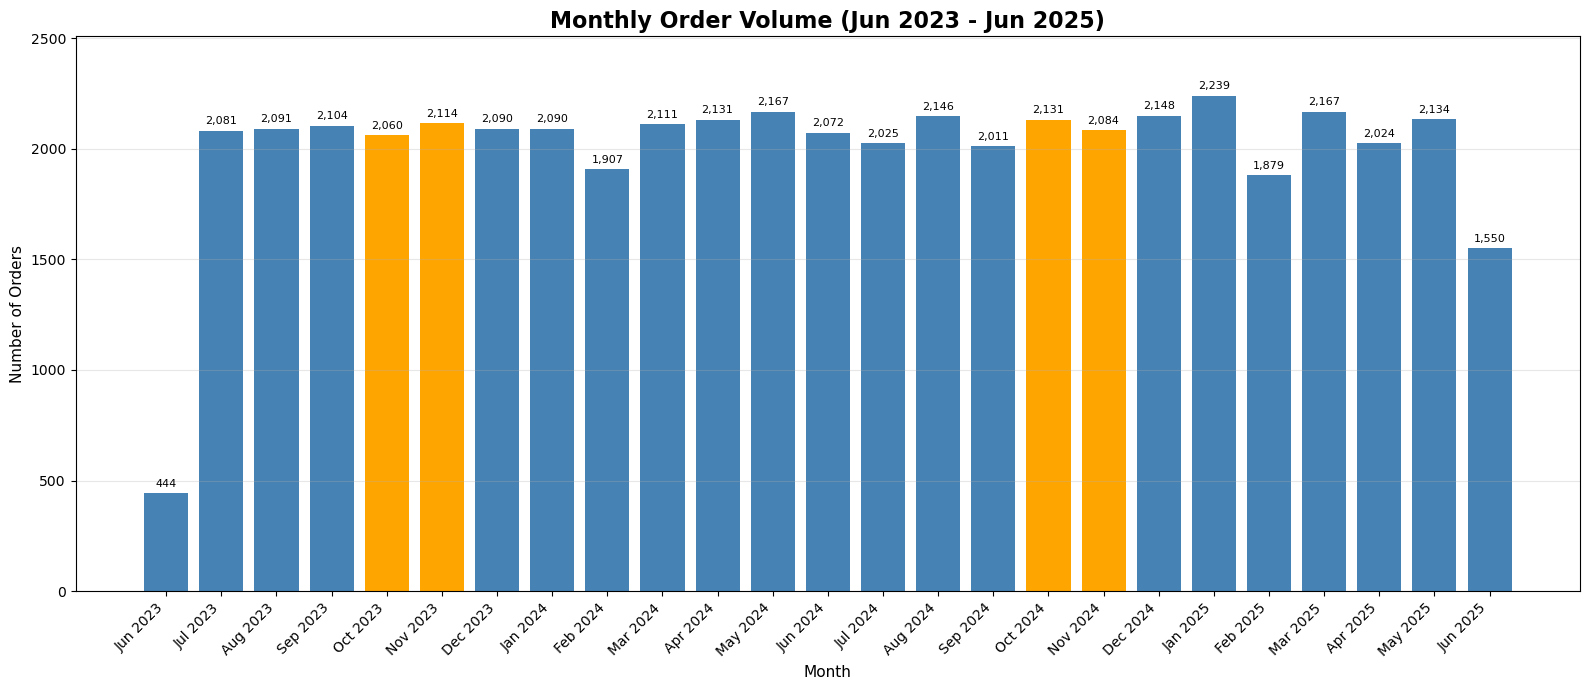

In [52]:
# Create readable month labels
monthly_orders['month_label'] = (
    monthly_orders['year_month']
    .dt.to_timestamp()
    .dt.strftime('%b %Y')
)

# Identify Diwali months (October and November)
is_diwali = monthly_orders['year_month'].dt.month.isin([10, 11])

bar_colors = [
    'orange' if diwali else 'steelblue'
    for diwali in is_diwali
]

# Create chart
plt.figure(figsize=(16, 7))

bars = plt.bar(
    monthly_orders['month_label'],
    monthly_orders['order_count'],
    color=bar_colors
)

# Add number of orders above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=0
    )

# Chart title and labels
plt.title(
    'Monthly Order Volume (Jun 2023 - Jun 2025)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)

plt.xticks(rotation=45, ha='right')

# Give space for data labels
plt.ylim(0, monthly_orders['order_count'].max() * 1.12)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save updated chart
plt.savefig(
    os.path.join(
        chart_folder,
        '01_monthly_order_volume.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Monthly order volume remained relatively stable across the full months, generally ranging between approximately 1,879 and 2,239 orders. The highest monthly order volume was recorded in January 2025 with 2,239 orders.

The highlighted Diwali months (October and November) did not show a major seasonal surge, with order volumes remaining close to the normal monthly range in both 2023 and 2024. June 2023 and June 2025 show lower volumes because the dataset contains only partial data for these months (24–30 June 2023 and 1–23 June 2025).

## 2. Monthly Revenue (GMV)

This analysis examines monthly Gross Merchandise Value (GMV) using the `final_amount` of all orders. Monthly revenue trends are analysed over time and compared year-over-year to identify changes in sales performance.

In [53]:
# Check final_amount before calculating GMV

print("Final Amount Data Type:")
print(orders['final_amount'].dtype)

print("\nMissing Values:")
print(orders['final_amount'].isna().sum())

print("\nFinal Amount Summary:")
print(orders['final_amount'].describe())

print("\nNegative Final Amounts:")
print((orders['final_amount'] < 0).sum())

print("\nZero Final Amounts:")
print((orders['final_amount'] == 0).sum())

Final Amount Data Type:
float64

Missing Values:
0

Final Amount Summary:
count    5.000000e+04
mean     6.294771e+04
std      9.789750e+04
min      1.360700e+02
25%      6.893520e+03
50%      2.418338e+04
75%      7.149574e+04
max      1.133382e+06
Name: final_amount, dtype: float64

Negative Final Amounts:
0

Zero Final Amounts:
0


In [54]:
# Calculate monthly GMV using final_amount

monthly_gmv = (
    orders.groupby('year_month')['final_amount']
    .sum()
    .reset_index(name='gmv')
)

# Display GMV in millions for easier reading
monthly_gmv['gmv_million'] = monthly_gmv['gmv'] / 1_000_000

print(monthly_gmv)

print("\nNumber of Months:", len(monthly_gmv))
print(f"Total GMV: ₹{monthly_gmv['gmv'].sum():,.2f}")

   year_month           gmv  gmv_million
0     2023-06  2.738485e+07    27.384849
1     2023-07  1.289205e+08   128.920509
2     2023-08  1.281220e+08   128.122037
3     2023-09  1.374625e+08   137.462483
4     2023-10  1.324709e+08   132.470874
5     2023-11  1.372634e+08   137.263359
6     2023-12  1.369234e+08   136.923402
7     2024-01  1.314500e+08   131.450025
8     2024-02  1.209459e+08   120.945866
9     2024-03  1.336701e+08   133.670054
10    2024-04  1.315097e+08   131.509731
11    2024-05  1.363584e+08   136.358367
12    2024-06  1.237410e+08   123.740980
13    2024-07  1.270283e+08   127.028266
14    2024-08  1.319235e+08   131.923460
15    2024-09  1.305253e+08   130.525274
16    2024-10  1.335183e+08   133.518341
17    2024-11  1.262641e+08   126.264142
18    2024-12  1.330895e+08   133.089460
19    2025-01  1.379291e+08   137.929117
20    2025-02  1.141167e+08   114.116741
21    2025-03  1.364932e+08   136.493234
22    2025-04  1.308222e+08   130.822234
23    2025-05  1

In [55]:
# Create Year and Month columns
monthly_gmv['year'] = monthly_gmv['year_month'].dt.year
monthly_gmv['month_num'] = monthly_gmv['year_month'].dt.month

# Month names
monthly_gmv['month_name'] = (
    monthly_gmv['year_month']
    .dt.to_timestamp()
    .dt.strftime('%b')
)

# Create Year-over-Year comparison table
gmv_yoy = monthly_gmv.pivot(
    index='month_num',
    columns='year',
    values='gmv_million'
)

# Add month names
gmv_yoy.index = [
    pd.Timestamp(2024, month, 1).strftime('%b')
    for month in gmv_yoy.index
]

# Round for readability
gmv_yoy = gmv_yoy.round(2)

gmv_yoy

year,2023,2024,2025
Jan,NaN,131.45,137.93
Feb,NaN,120.95,114.12
Mar,NaN,133.67,136.49
Apr,NaN,131.51,130.82
May,NaN,136.36,135.85
Jun,27.38,123.74,103.60
Jul,128.92,127.03,NaN
Aug,128.12,131.92,NaN
Sep,137.46,130.53,NaN
Oct,132.47,133.52,NaN


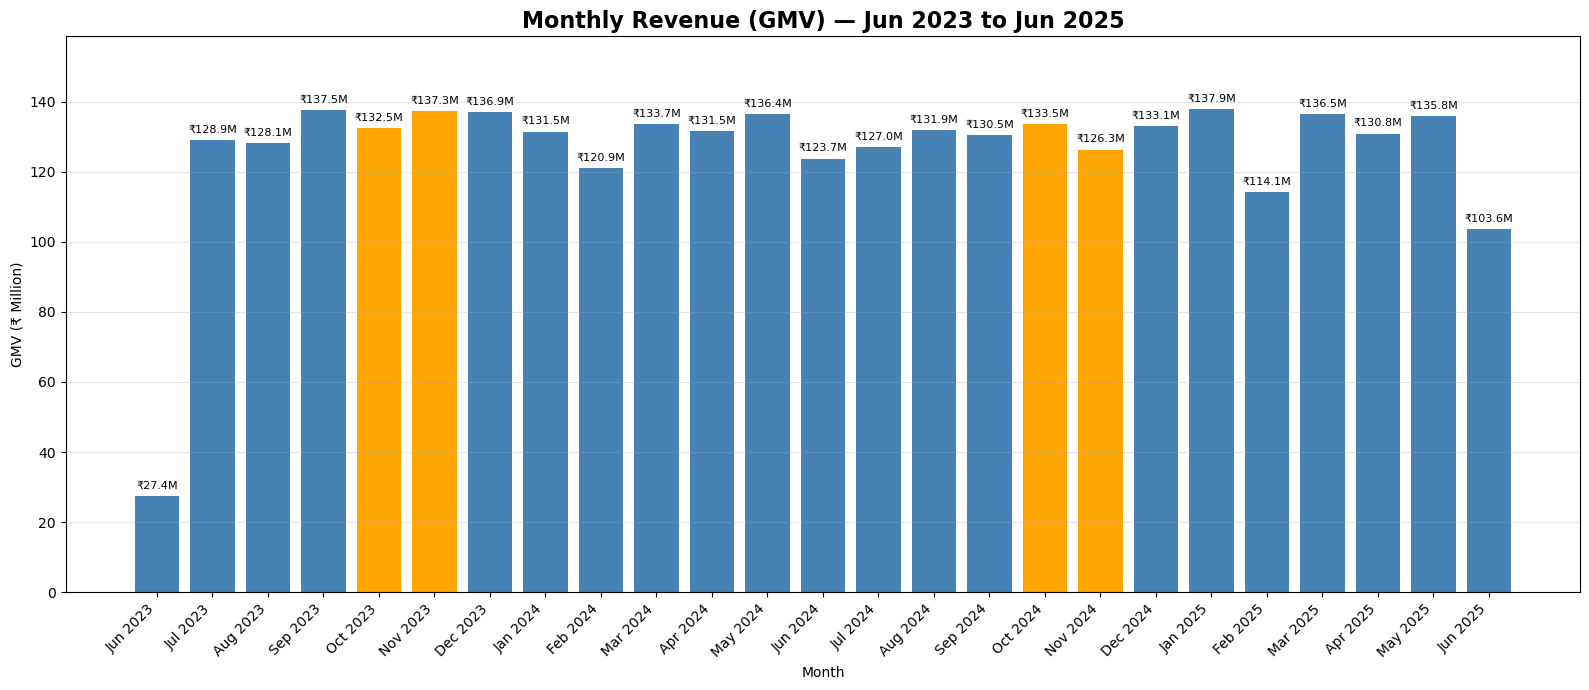

In [56]:
# Create readable month labels
monthly_gmv['month_label'] = (
    monthly_gmv['year_month']
    .dt.to_timestamp()
    .dt.strftime('%b %Y')
)

# Highlight October and November
is_diwali = monthly_gmv['year_month'].dt.month.isin([10, 11])

bar_colors = [
    'orange' if diwali else 'steelblue'
    for diwali in is_diwali
]

# Create chart
plt.figure(figsize=(16, 7))

bars = plt.bar(
    monthly_gmv['month_label'],
    monthly_gmv['gmv_million'],
    color=bar_colors
)

# Add GMV values above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'₹{height:.1f}M',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title(
    'Monthly Revenue (GMV) — Jun 2023 to Jun 2025',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('GMV (₹ Million)')

plt.xticks(rotation=45, ha='right')

plt.ylim(
    0,
    monthly_gmv['gmv_million'].max() * 1.15
)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '02_monthly_revenue_gmv.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

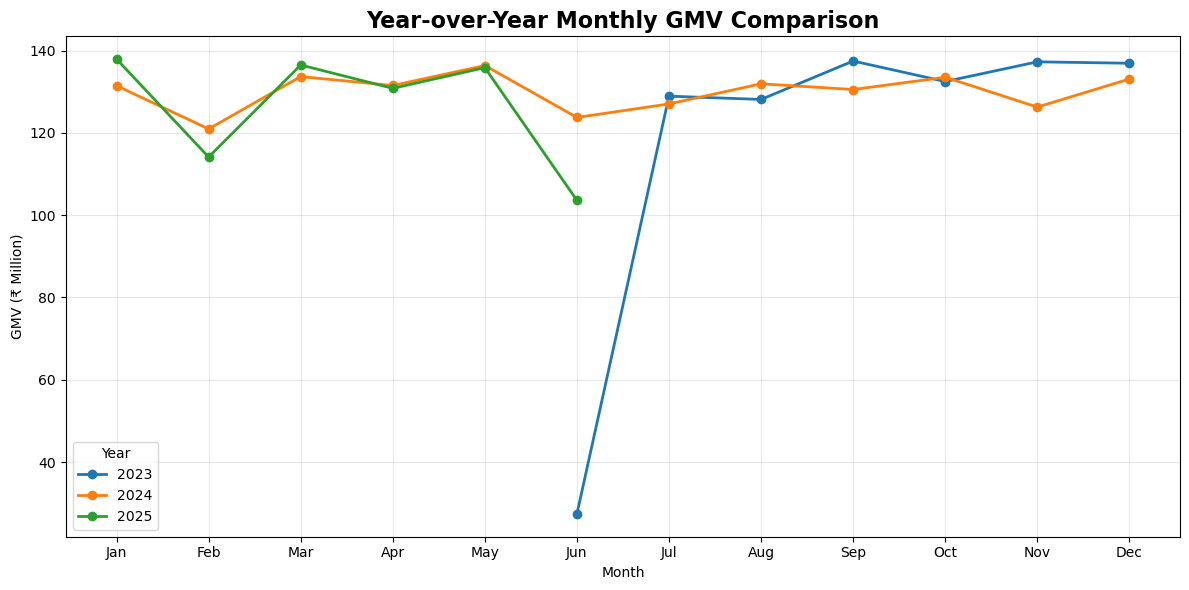

In [57]:
# Year-over-Year Monthly GMV Comparison

plt.figure(figsize=(12, 6))

for year in gmv_yoy.columns:
    plt.plot(
        gmv_yoy.index,
        gmv_yoy[year],
        marker='o',
        linewidth=2,
        label=str(year)
    )

plt.title(
    'Year-over-Year Monthly GMV Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('GMV (₹ Million)')

plt.legend(title='Year')

plt.grid(alpha=0.3)

plt.tight_layout()

# Save as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '02b_gmv_year_over_year.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Monthly GMV remained relatively stable across the complete months, generally ranging between approximately ₹114 million and ₹138 million. January 2025 recorded the highest monthly GMV at approximately ₹137.93 million, while February 2025 was one of the weaker complete months at approximately ₹114.12 million.

The year-over-year comparison shows mixed performance rather than consistent growth: January and March 2025 were higher than the same months in 2024, while February, April, and May 2025 were slightly lower. Diwali performance was also mixed, with October 2024 slightly outperforming October 2023, while November 2024 declined compared with November 2023; June 2023 and June 2025 should not be directly compared because both are partial months.

## 3. Category-wise Revenue Share

This analysis examines the contribution of each product category to total item-level revenue. The objective is to identify the categories generating the highest revenue and understand their relative share of overall sales.


In [58]:
# Validate category and total_price columns

print("Category Missing Values:")
print(order_items['category'].isna().sum())

print("\nTotal Price Data Type:")
print(order_items['total_price'].dtype)

print("\nTotal Price Missing Values:")
print(order_items['total_price'].isna().sum())

print("\nNegative Total Price Values:")
print((order_items['total_price'] < 0).sum())

print("\nZero Total Price Values:")
print((order_items['total_price'] == 0).sum())

print("\nUnique Categories:")
print(order_items['category'].nunique())

print("\nCategory Names:")
print(order_items['category'].value_counts())

Category Missing Values:
0

Total Price Data Type:
float64

Total Price Missing Values:
0

Negative Total Price Values:
0

Zero Total Price Values:
0

Unique Categories:
10

Category Names:
category
Office Supplies     10152
Home & Kitchen      10109
Electronics         10090
Grocery             10026
Fashion             10002
Toys & Baby          9989
Automotive           9986
Books                9949
Sports & Fitness     9903
Beauty & Health      9794
Name: count, dtype: int64


In [59]:
# Join order items with order status

category_check = order_items.merge(
    orders[['order_id', 'status']],
    on='order_id',
    how='left'
)

print("Rows after merge:", len(category_check))

print("\nMissing Order Status:")
print(category_check['status'].isna().sum())

print("\nOrder Items by Order Status:")
print(category_check['status'].value_counts())

print("\nTotal Item Value by Order Status:")

status_value = (
    category_check
    .groupby('status')['total_price']
    .sum()
    .sort_values(ascending=False)
)

print(status_value)

Rows after merge: 100000

Missing Order Status:
0

Order Items by Order Status:
status
Delivered     64951
Cancelled     12007
Shipped       10109
Returned       7898
Processing     5035
Name: count, dtype: int64

Total Item Value by Order Status:
status
Delivered     1.864169e+09
Cancelled     3.342606e+08
Shipped       2.900365e+08
Returned      2.286236e+08
Processing    1.438025e+08
Name: total_price, dtype: float64


In [60]:
# Keep only items belonging to Delivered orders
delivered_items = category_check[
    category_check['status'] == 'Delivered'
].copy()

# Calculate category-wise revenue
category_revenue = (
    delivered_items
    .groupby('category')['total_price']
    .sum()
    .reset_index(name='revenue')
)

# Calculate revenue share
total_delivered_item_revenue = category_revenue['revenue'].sum()

category_revenue['revenue_share_pct'] = (
    category_revenue['revenue']
    / total_delivered_item_revenue
    * 100
)

# Revenue in millions for easier interpretation
category_revenue['revenue_million'] = (
    category_revenue['revenue'] / 1_000_000
)

# Sort highest to lowest
category_revenue = category_revenue.sort_values(
    'revenue',
    ascending=False
)

# Round display columns
category_revenue['revenue_million'] = (
    category_revenue['revenue_million'].round(2)
)

category_revenue['revenue_share_pct'] = (
    category_revenue['revenue_share_pct'].round(2)
)

print(category_revenue)

print(
    f"\nTotal Delivered Item Revenue: "
    f"₹{total_delivered_item_revenue:,.2f}"
)

           category       revenue  revenue_share_pct  revenue_million
3       Electronics  1.076374e+09              57.74          1076.37
8  Sports & Fitness  3.192419e+08              17.13           319.24
6    Home & Kitchen  1.576279e+08               8.46           157.63
4           Fashion  9.691033e+07               5.20            96.91
0        Automotive  8.063293e+07               4.33            80.63
7   Office Supplies  6.070733e+07               3.26            60.71
9       Toys & Baby  2.990482e+07               1.60            29.90
1   Beauty & Health  2.168397e+07               1.16            21.68
5           Grocery  1.207455e+07               0.65            12.07
2             Books  9.011382e+06               0.48             9.01

Total Delivered Item Revenue: ₹1,864,169,495.81


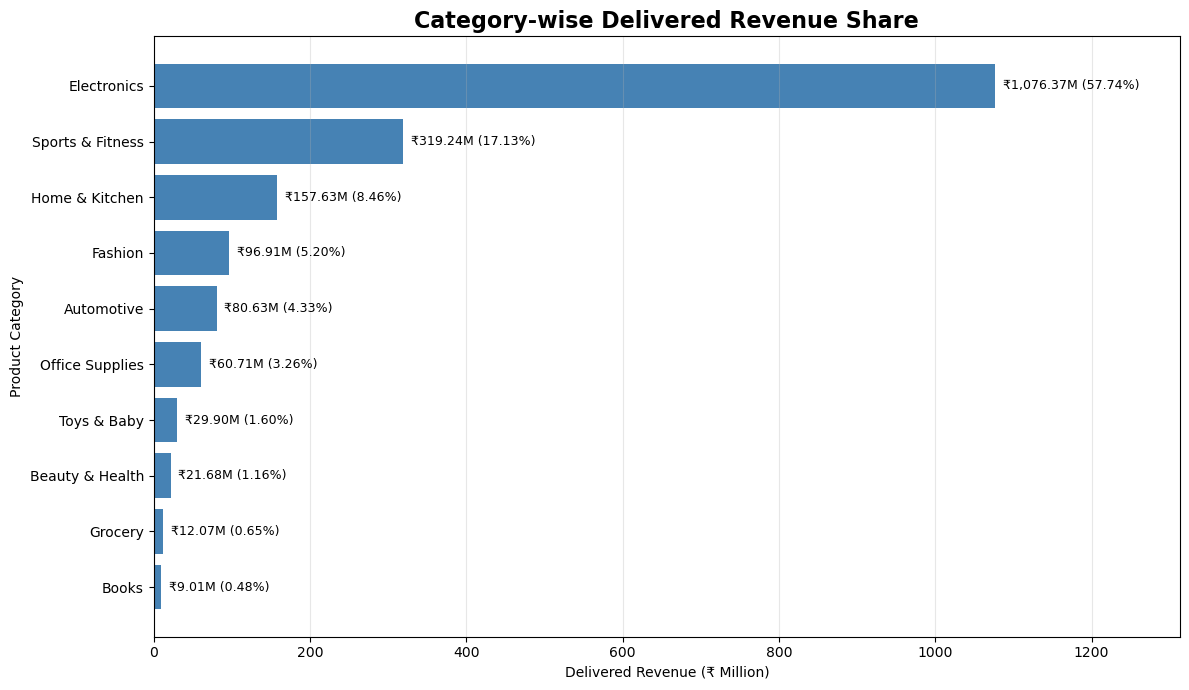

In [61]:
# Sort categories from lowest to highest for horizontal bar chart
category_plot = category_revenue.sort_values(
    'revenue_million',
    ascending=True
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    category_plot['category'],
    category_plot['revenue_million'],
    color='steelblue'
)

# Add revenue and percentage labels
for bar, revenue, share in zip(
    bars,
    category_plot['revenue_million'],
    category_plot['revenue_share_pct']
):
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f'₹{revenue:,.2f}M ({share:.2f}%)',
        va='center',
        fontsize=9
    )

plt.title(
    'Category-wise Delivered Revenue Share',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Delivered Revenue (₹ Million)')
plt.ylabel('Product Category')

# Extra space for labels
plt.xlim(
    0,
    category_plot['revenue_million'].max() * 1.22
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save chart as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '03_category_revenue_share.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Electronics is the highest revenue-generating category, contributing approximately ₹1,076.37 million or 57.74% of total delivered item revenue. Sports & Fitness ranks second with ₹319.24 million (17.13%), followed by Home & Kitchen with ₹157.63 million (8.46%).

The results show that IndiaKart's delivered revenue is heavily concentrated in Electronics, with more than half of the total category revenue coming from this single category.

## 4. Order Status Distribution

This analysis examines the distribution of orders across different fulfillment statuses. It helps assess the proportion of successfully delivered orders compared with cancelled, returned, shipped, and processing orders.

In [62]:
# Calculate order status distribution

status_distribution = (
    orders['status']
    .value_counts()
    .reset_index()
)

status_distribution.columns = ['status', 'order_count']

# Calculate percentage
status_distribution['percentage'] = (
    status_distribution['order_count']
    / status_distribution['order_count'].sum()
    * 100
)

status_distribution['percentage'] = (
    status_distribution['percentage'].round(2)
)

print(status_distribution)

print("\nTotal Orders:",
      status_distribution['order_count'].sum())

       status  order_count  percentage
0   Delivered        32499       65.00
1   Cancelled         5996       11.99
2     Shipped         5071       10.14
3    Returned         3933        7.87
4  Processing         2501        5.00

Total Orders: 50000


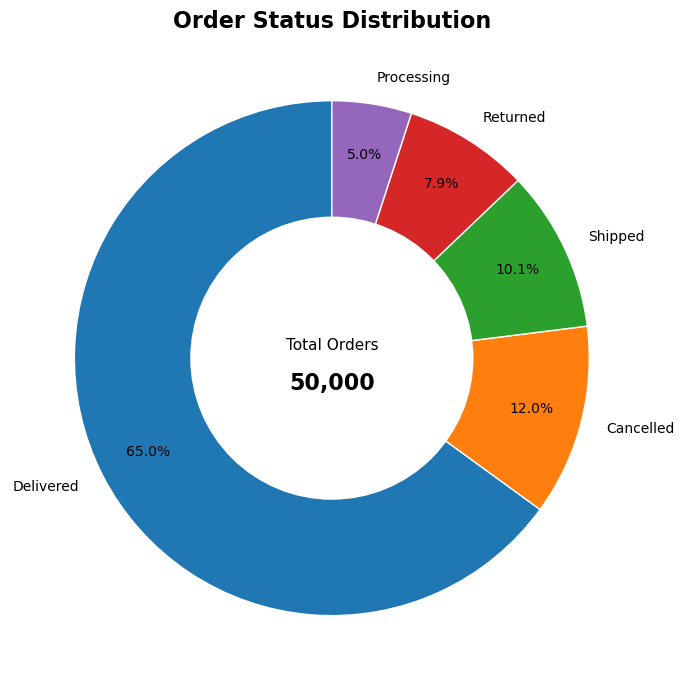

In [63]:
# Create donut chart for order status distribution

plt.figure(figsize=(9, 7))

wedges, texts, autotexts = plt.pie(
    status_distribution['order_count'],
    labels=status_distribution['status'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80,
    wedgeprops={'edgecolor': 'white'}
)

# Create centre circle for donut shape
centre_circle = plt.Circle(
    (0, 0),
    0.55,
    fc='white'
)

plt.gca().add_artist(centre_circle)

# Add total orders in the centre
plt.text(
    0,
    0.05,
    'Total Orders',
    ha='center',
    va='center',
    fontsize=11
)

plt.text(
    0,
    -0.10,
    f"{status_distribution['order_count'].sum():,}",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    'Order Status Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

# Save chart as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '04_order_status_distribution.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Delivered orders account for the largest share of total orders at 65.0%, indicating that nearly two-thirds of all orders were successfully completed. Cancelled orders represent 12.0%, while 7.9% of orders were returned.

The combined share of cancelled and returned orders is approximately 19.9%, suggesting an important opportunity to investigate cancellation and return drivers and improve overall order fulfillment performance.

## 5. Top 10 States by Number of Orders

This analysis identifies the states generating the highest number of orders. Understanding geographic order concentration can help the business prioritize marketing, logistics, inventory planning, and customer acquisition efforts across key markets.

In [64]:
# Validate state column in orders dataset

print("State Data Type:")
print(orders['state'].dtype)

print("\nMissing State Values:")
print(orders['state'].isna().sum())

print("\nNumber of Unique States:")
print(orders['state'].nunique())

print("\nOrders by State:")
print(orders['state'].value_counts())

State Data Type:
object

Missing State Values:
0

Number of Unique States:
18

Orders by State:
state
Uttar Pradesh      9507
Maharashtra        8179
Gujarat            3811
Madhya Pradesh     3741
Tamil Nadu         3664
Karnataka          3102
Rajasthan          3047
West Bengal        2103
Punjab             2073
Jharkhand          2044
Andhra Pradesh     1803
Chhattisgarh       1102
Delhi              1046
Assam              1027
Chandigarh          966
Jammu & Kashmir     956
Telangana           927
Haryana             902
Name: count, dtype: int64


In [65]:
# Calculate Top 10 states by number of unique orders

top_10_states = (
    orders.groupby('state')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='order_count')
)

# Calculate share of total orders
top_10_states['order_share_pct'] = (
    top_10_states['order_count']
    / orders['order_id'].nunique()
    * 100
).round(2)

print(top_10_states)

print(
    "\nOrders from Top 10 States:",
    f"{top_10_states['order_count'].sum():,}"
)

print(
    "Top 10 Share of Total Orders:",
    f"{top_10_states['order_share_pct'].sum():.2f}%"
)

            state  order_count  order_share_pct
0   Uttar Pradesh         9507            19.01
1     Maharashtra         8179            16.36
2         Gujarat         3811             7.62
3  Madhya Pradesh         3741             7.48
4      Tamil Nadu         3664             7.33
5       Karnataka         3102             6.20
6       Rajasthan         3047             6.09
7     West Bengal         2103             4.21
8          Punjab         2073             4.15
9       Jharkhand         2044             4.09

Orders from Top 10 States: 41,271
Top 10 Share of Total Orders: 82.54%


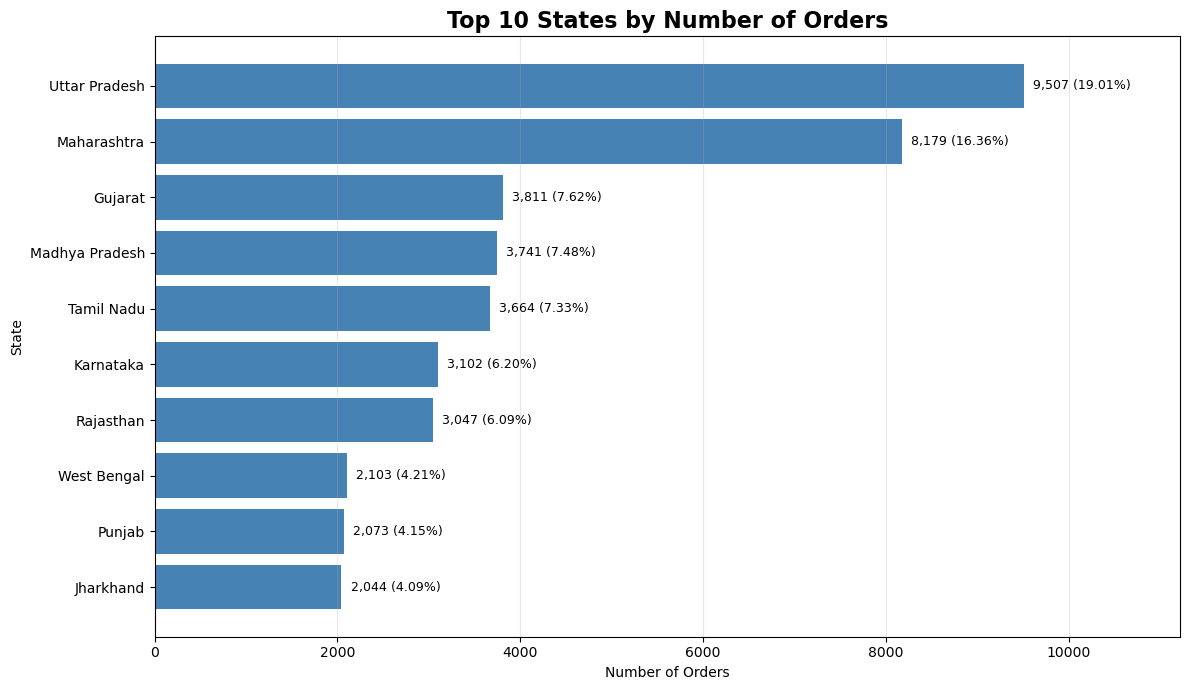

In [66]:
# Sort for horizontal bar chart
top_10_states_plot = top_10_states.sort_values(
    'order_count',
    ascending=True
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_10_states_plot['state'],
    top_10_states_plot['order_count'],
    color='steelblue'
)

# Add order count and percentage labels
for bar, count, share in zip(
    bars,
    top_10_states_plot['order_count'],
    top_10_states_plot['order_share_pct']
):
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({share:.2f}%)',
        va='center',
        fontsize=9
    )

plt.title(
    'Top 10 States by Number of Orders',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Orders')
plt.ylabel('State')

# Give space for labels
plt.xlim(
    0,
    top_10_states_plot['order_count'].max() * 1.18
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '05_top_10_states_by_orders.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Uttar Pradesh generated the highest number of orders with 9,507 orders (19.01%), followed by Maharashtra with 8,179 orders (16.36%). Together, these two states contributed approximately 35.37% of all orders, showing a strong concentration of demand in these markets.

The top 10 states accounted for 41,271 orders, or 82.54% of total order volume, indicating that a large majority of IndiaKart's orders are concentrated within a relatively small group of states.

## 6. Customer Segment Distribution

This analysis examines the distribution of customers across different customer segments. It helps understand the composition of the customer base and identify which segments represent the largest share of IndiaKart's customers.

In [67]:
# Validate customer segment data

print("Segment Data Type:")
print(customers['segment'].dtype)

print("\nMissing Segment Values:")
print(customers['segment'].isna().sum())

print("\nNumber of Unique Segments:")
print(customers['segment'].nunique())

print("\nCustomer Count by Segment:")
print(customers['segment'].value_counts())

Segment Data Type:
object

Missing Segment Values:
0

Number of Unique Segments:
5

Customer Count by Segment:
segment
Regular     4026
Budget      2505
Premium     1501
New         1488
Inactive     480
Name: count, dtype: int64


In [68]:
# Calculate customer segment distribution

segment_distribution = (
    customers['segment']
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ['segment', 'customer_count']

# Calculate percentage share
segment_distribution['percentage'] = (
    segment_distribution['customer_count']
    / segment_distribution['customer_count'].sum()
    * 100
).round(2)

print(segment_distribution)

print(
    "\nTotal Customers:",
    segment_distribution['customer_count'].sum()
)

    segment  customer_count  percentage
0   Regular            4026       40.26
1    Budget            2505       25.05
2   Premium            1501       15.01
3       New            1488       14.88
4  Inactive             480        4.80

Total Customers: 10000


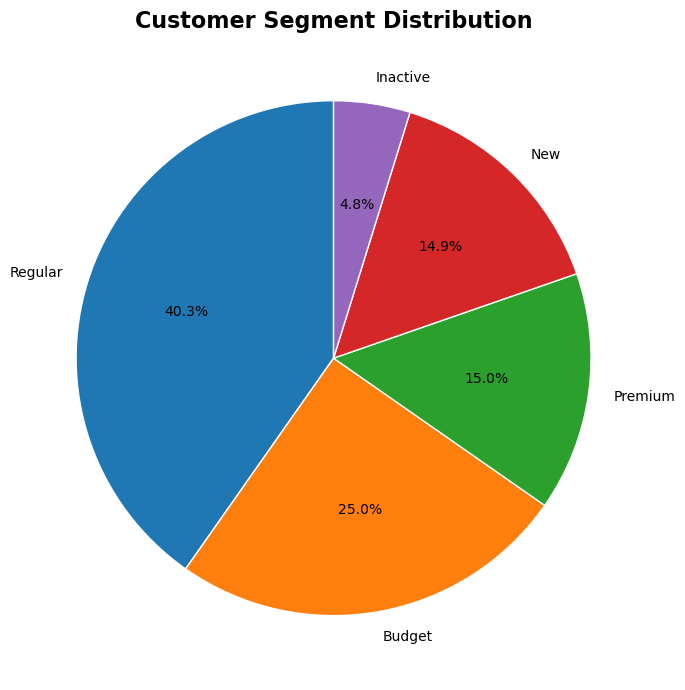

In [69]:
plt.figure(figsize=(9, 7))

plt.pie(
    segment_distribution['customer_count'],
    labels=segment_distribution['segment'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title(
    'Customer Segment Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

# Save chart as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '06_customer_segment_distribution.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Regular customers form the largest customer segment with 4,026 customers, representing 40.26% of the total customer base. Budget customers are the second-largest segment with 2,505 customers (25.05%), while Premium customers account for 1,501 customers (15.01%).

Together, Regular and Budget customers represent 65.31% of IndiaKart's customer base, indicating that these two segments make up the majority of customers.

## 7. Payment Method Usage

This analysis examines the payment methods used by customers while placing orders. The objective is to identify the most popular payment options and understand customer payment preferences on the IndiaKart platform.

In [70]:
# Validate payment method data

print("Payment Method Data Type:")
print(orders['payment_method'].dtype)

print("\nMissing Payment Method Values:")
print(orders['payment_method'].isna().sum())

print("\nNumber of Unique Payment Methods:")
print(orders['payment_method'].nunique())

print("\nPayment Method Usage:")
print(orders['payment_method'].value_counts())

Payment Method Data Type:
object

Missing Payment Method Values:
0

Number of Unique Payment Methods:
7

Payment Method Usage:
payment_method
UPI                 17570
Credit Card         10007
Debit Card           7624
Cash on Delivery     5883
Net Banking          4026
EMI                  2943
Wallet               1947
Name: count, dtype: int64


In [71]:
# Calculate payment method usage

payment_usage = (
    orders['payment_method']
    .value_counts()
    .reset_index()
)

payment_usage.columns = ['payment_method', 'order_count']

# Calculate percentage share
payment_usage['percentage'] = (
    payment_usage['order_count']
    / payment_usage['order_count'].sum()
    * 100
).round(2)

print(payment_usage)

print(
    "\nTotal Orders:",
    payment_usage['order_count'].sum()
)

     payment_method  order_count  percentage
0               UPI        17570       35.14
1       Credit Card        10007       20.01
2        Debit Card         7624       15.25
3  Cash on Delivery         5883       11.77
4       Net Banking         4026        8.05
5               EMI         2943        5.89
6            Wallet         1947        3.89

Total Orders: 50000


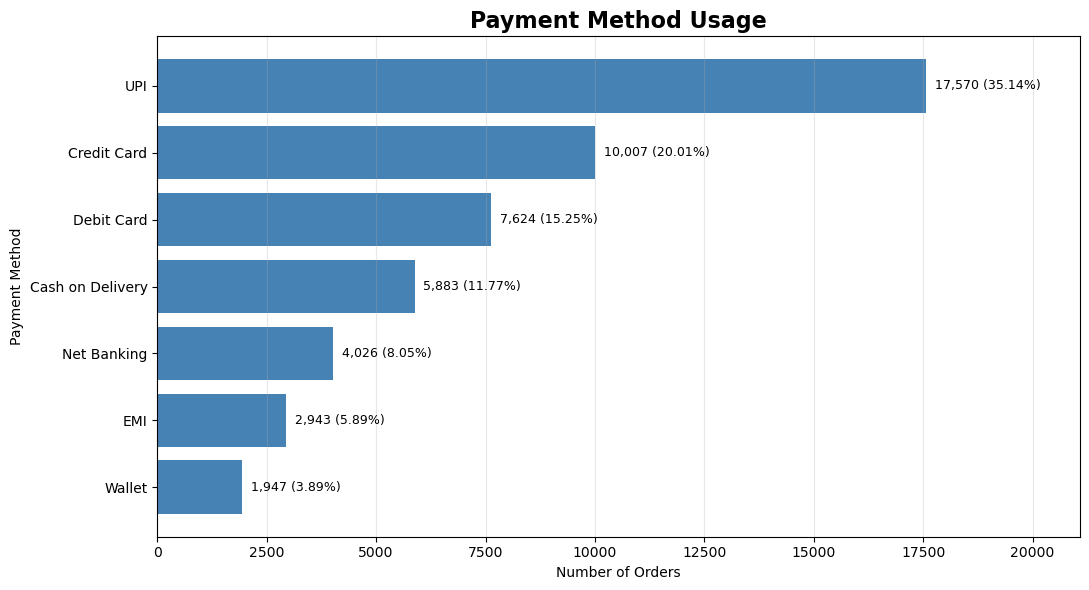

In [72]:
# Sort payment methods for horizontal bar chart
payment_plot = payment_usage.sort_values(
    'order_count',
    ascending=True
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    payment_plot['payment_method'],
    payment_plot['order_count'],
    color='steelblue'
)

# Add order count and percentage labels
for bar, count, share in zip(
    bars,
    payment_plot['order_count'],
    payment_plot['percentage']
):
    plt.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({share:.2f}%)',
        va='center',
        fontsize=9
    )

plt.title(
    'Payment Method Usage',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Orders')
plt.ylabel('Payment Method')

plt.xlim(
    0,
    payment_plot['order_count'].max() * 1.20
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save chart as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '07_payment_method_usage.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

UPI is the most popular payment method, used for 17,570 orders and accounting for 35.14% of all transactions. Credit Cards rank second at 20.01%, followed by Debit Cards at 15.25%.

Digital payment methods dominate customer payment behaviour, while Cash on Delivery accounts for only 11.77% of orders. Wallet is the least-used payment option, representing just 3.89% of total orders.

## 8. Age Distribution of Customers

This analysis examines the age distribution of IndiaKart customers to understand the demographic composition of the customer base and identify the age groups with the strongest representation.

In [73]:
# Validate customer age data

print("Age Data Type:")
print(customers['age'].dtype)

print("\nMissing Age Values:")
print(customers['age'].isna().sum())

print("\nAge Summary:")
print(customers['age'].describe())

print("\nMinimum Age:")
print(customers['age'].min())

print("\nMaximum Age:")
print(customers['age'].max())

print("\nCustomers Below 18:")
print((customers['age'] < 18).sum())

print("\nCustomers Above 100:")
print((customers['age'] > 100).sum())

Age Data Type:
int64

Missing Age Values:
0

Age Summary:
count    10000.00000
mean        41.67630
std         13.83438
min         18.00000
25%         30.00000
50%         42.00000
75%         54.00000
max         65.00000
Name: age, dtype: float64

Minimum Age:
18

Maximum Age:
65

Customers Below 18:
0

Customers Above 100:
0


In [74]:
# Create customer age groups

age_bins = [17, 24, 34, 44, 54, 65]

age_labels = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-65'
]

customers['age_group'] = pd.cut(
    customers['age'],
    bins=age_bins,
    labels=age_labels
)

# Count customers in each age group
age_group_distribution = (
    customers['age_group']
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_distribution.columns = [
    'age_group',
    'customer_count'
]

# Calculate percentage
age_group_distribution['percentage'] = (
    age_group_distribution['customer_count']
    / len(customers)
    * 100
).round(2)

print(age_group_distribution)

print(
    "\nTotal Customers:",
    age_group_distribution['customer_count'].sum()
)

  age_group  customer_count  percentage
0     18-24            1429       14.29
1     25-34            2037       20.37
2     35-44            2171       21.71
3     45-54            1996       19.96
4     55-65            2367       23.67

Total Customers: 10000


In [75]:
# Join orders with customer age information

orders_by_age = orders.merge(
    customers[['customer_id', 'age', 'age_group']],
    on='customer_id',
    how='left'
)

print("Rows After Merge:", len(orders_by_age))

print("\nMissing Age Groups:")
print(orders_by_age['age_group'].isna().sum())

# Calculate orders by age group
age_group_orders = (
    orders_by_age
    .groupby('age_group', observed=False)['order_id']
    .nunique()
    .reset_index(name='order_count')
)

# Calculate percentage of total orders
age_group_orders['order_share_pct'] = (
    age_group_orders['order_count']
    / orders['order_id'].nunique()
    * 100
).round(2)

print("\nOrders by Age Group:")
print(age_group_orders)

print(
    "\nTotal Orders:",
    age_group_orders['order_count'].sum()
)

Rows After Merge: 50000

Missing Age Groups:
0

Orders by Age Group:
  age_group  order_count  order_share_pct
0     18-24         7075            14.15
1     25-34        10096            20.19
2     35-44        10766            21.53
3     45-54        10012            20.02
4     55-65        12051            24.10

Total Orders: 50000


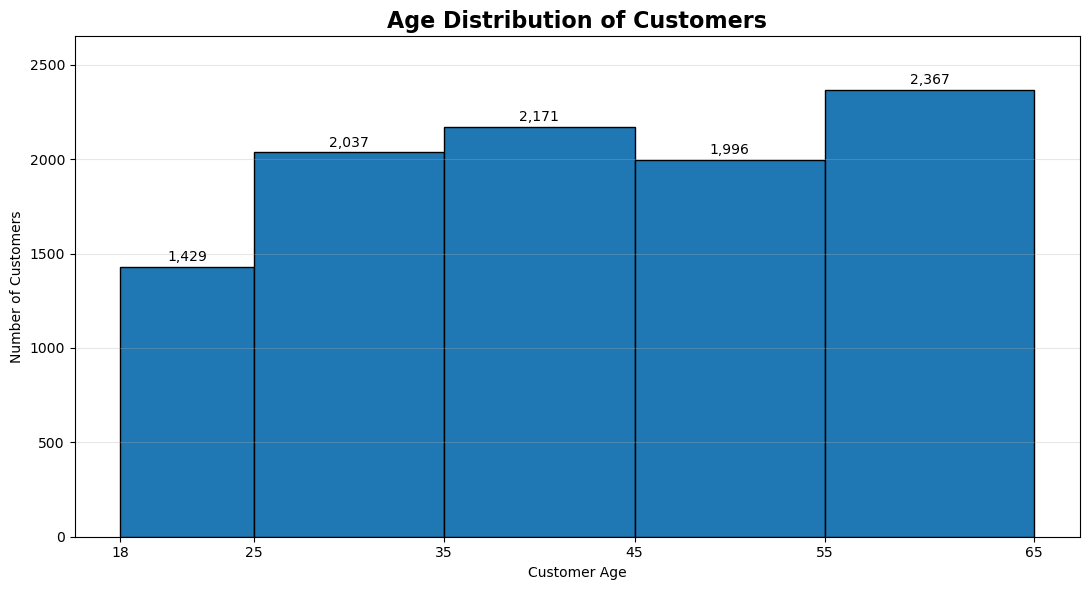

In [76]:
# Create age distribution histogram

plt.figure(figsize=(11, 6))

bins = [18, 25, 35, 45, 55, 66]

counts, bins, patches = plt.hist(
    customers['age'],
    bins=bins,
    edgecolor='black'
)

# Add customer counts above each bar
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count + 30,
        f'{int(count):,}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Age Distribution of Customers',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')

plt.xticks(
    [18, 25, 35, 45, 55, 66],
    ['18', '25', '35', '45', '55', '65']
)

plt.ylim(0, max(counts) * 1.12)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '08_customer_age_distribution.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Customers aged 55–65 form the largest age group, with 2,367 customers (23.67% of the customer base). This group also generated the highest number of orders at 12,051, representing 24.10% of total orders.

The 18–24 age group has the lowest representation with 1,429 customers and contributes 7,075 orders (14.15%). Overall, the analysis indicates that older customers, particularly those aged 55–65, are the most active shopping group on IndiaKart.

## 9. Return Reasons

This analysis examines the reasons customers return their orders. The objective is to identify the most common causes of returns and highlight areas where product quality, fulfillment, delivery, or customer experience may need improvement.

In [77]:
# Validate return reason data

print("Return Reason Data Type:")
print(returns['reason'].dtype)

print("\nMissing Return Reasons:")
print(returns['reason'].isna().sum())

print("\nNumber of Unique Return Reasons:")
print(returns['reason'].nunique())

print("\nReturn Reasons:")
print(returns['reason'].value_counts())

print("\nTotal Return Records:")
print(len(returns))

Return Reason Data Type:
object

Missing Return Reasons:
0

Number of Unique Return Reasons:
10

Return Reasons:
reason
Size Issue                 1196
Changed Mind               1150
Damaged in Transit         1143
Wrong Product Delivered    1135
Defective Product          1134
Not as Described           1125
Duplicate Order            1081
Quality Issue              1075
Delayed Delivery            484
Better Price Found          477
Name: count, dtype: int64

Total Return Records:
10000


In [78]:
# Calculate return reason distribution

return_reason_distribution = (
    returns['reason']
    .value_counts()
    .reset_index()
)

return_reason_distribution.columns = [
    'return_reason',
    'return_count'
]

# Calculate percentage share
return_reason_distribution['percentage'] = (
    return_reason_distribution['return_count']
    / return_reason_distribution['return_count'].sum()
    * 100
).round(2)

print(return_reason_distribution)

print(
    "\nTotal Returns:",
    return_reason_distribution['return_count'].sum()
)

             return_reason  return_count  percentage
0               Size Issue          1196       11.96
1             Changed Mind          1150       11.50
2       Damaged in Transit          1143       11.43
3  Wrong Product Delivered          1135       11.35
4        Defective Product          1134       11.34
5         Not as Described          1125       11.25
6          Duplicate Order          1081       10.81
7            Quality Issue          1075       10.75
8         Delayed Delivery           484        4.84
9       Better Price Found           477        4.77

Total Returns: 10000


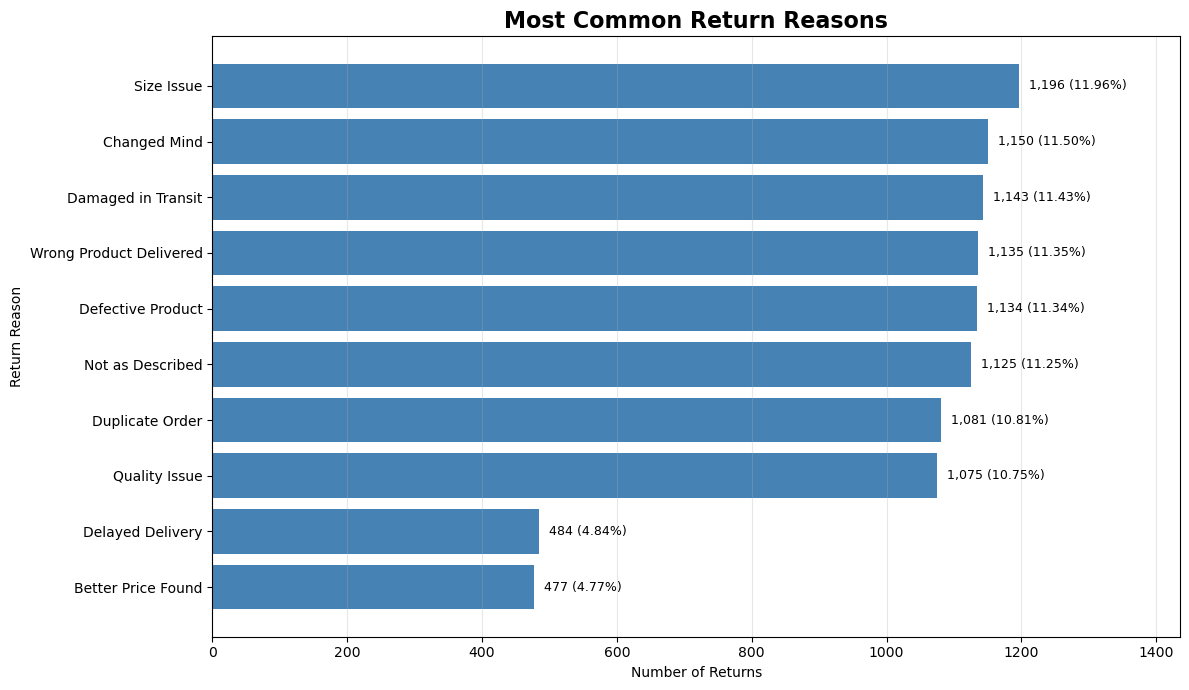

In [79]:
# Sort return reasons for horizontal bar chart
return_reason_plot = return_reason_distribution.sort_values(
    'return_count',
    ascending=True
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    return_reason_plot['return_reason'],
    return_reason_plot['return_count'],
    color='steelblue'
)

# Add return count and percentage labels
for bar, count, share in zip(
    bars,
    return_reason_plot['return_count'],
    return_reason_plot['percentage']
):
    plt.text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({share:.2f}%)',
        va='center',
        fontsize=9
    )

plt.title(
    'Most Common Return Reasons',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Returns')
plt.ylabel('Return Reason')

plt.xlim(
    0,
    return_reason_plot['return_count'].max() * 1.20
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save chart as PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '09_return_reasons.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Size Issue is the most common return reason with 1,196 returns (11.96%), followed by Changed Mind with 1,150 returns (11.50%) and Damaged in Transit with 1,143 returns (11.43%).

Return reasons are relatively distributed across several major causes rather than being dominated by a single issue. Product and fulfillment-related problems such as damaged products, wrong products, defects, quality issues, and inaccurate descriptions represent important areas where IndiaKart could focus to reduce returns.

## 10. Average Order Value (AOV) by Customer Segment

This analysis compares the Average Order Value (AOV) across customer segments. The objective is to determine which customer segments spend more per order and specifically assess whether Premium customers have a higher AOV than other segments.

In [80]:
# Merge orders with customer segment

orders_segment = orders.merge(
    customers[['customer_id', 'segment']],
    on='customer_id',
    how='left'
)

print("Original Orders:", len(orders))
print("Rows After Merge:", len(orders_segment))

print("\nMissing Customer Segments:")
print(orders_segment['segment'].isna().sum())

print("\nOrders by Customer Segment:")
print(orders_segment['segment'].value_counts())

print("\nUnique Orders After Merge:")
print(orders_segment['order_id'].nunique())

Original Orders: 50000
Rows After Merge: 50000

Missing Customer Segments:
0

Orders by Customer Segment:
segment
Regular     23080
Premium     12923
Budget       7273
New          6453
Inactive      271
Name: count, dtype: int64

Unique Orders After Merge:
50000


In [81]:
# Calculate AOV by customer segment

segment_aov = (
    orders_segment
    .groupby('segment')
    .agg(
        total_order_value=('final_amount', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# Calculate Average Order Value
segment_aov['aov'] = (
    segment_aov['total_order_value']
    / segment_aov['total_orders']
)

# Sort from highest to lowest AOV
segment_aov = segment_aov.sort_values(
    'aov',
    ascending=False
)

# Round values for readability
segment_aov['total_order_value'] = (
    segment_aov['total_order_value'].round(2)
)

segment_aov['aov'] = segment_aov['aov'].round(2)

print(segment_aov)

    segment  total_order_value  total_orders       aov
0    Budget       4.663779e+08          7273  64124.56
2       New       4.090013e+08          6453  63381.58
4   Regular       1.456892e+09         23080  63123.55
3   Premium       7.996352e+08         12923  61876.90
1  Inactive       1.547956e+07           271  57120.14


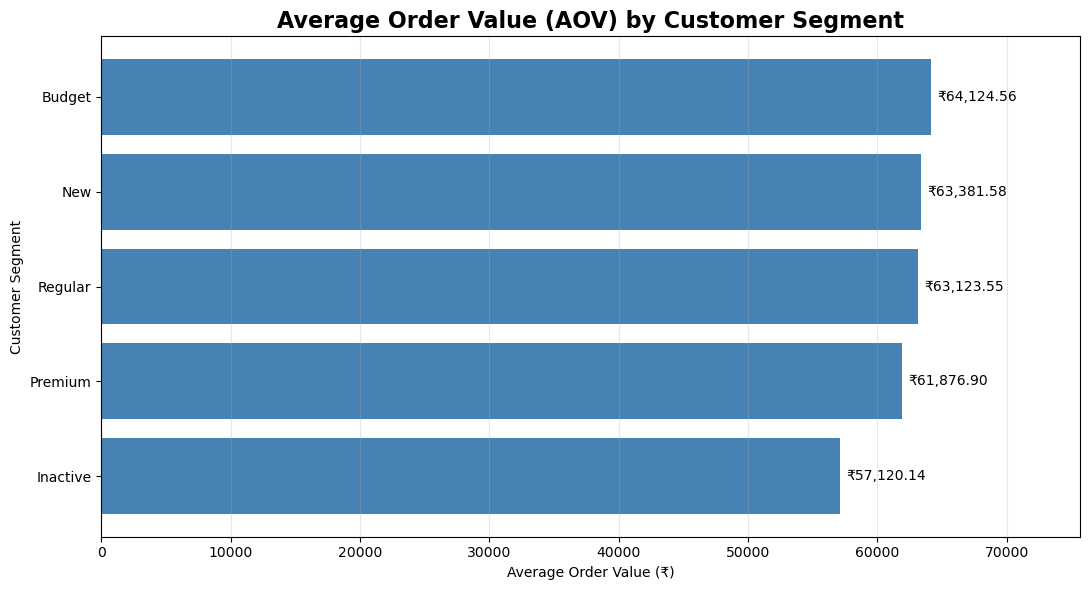

In [82]:
# Sort data for horizontal bar chart
segment_aov_plot = segment_aov.sort_values(
    'aov',
    ascending=True
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    segment_aov_plot['segment'],
    segment_aov_plot['aov'],
    color='steelblue'
)

# Add AOV labels
for bar, aov in zip(
    bars,
    segment_aov_plot['aov']
):
    plt.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'₹{aov:,.2f}',
        va='center',
        fontsize=10
    )

plt.title(
    'Average Order Value (AOV) by Customer Segment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Order Value (₹)')
plt.ylabel('Customer Segment')

# Start from zero to avoid exaggerating differences
plt.xlim(
    0,
    segment_aov_plot['aov'].max() * 1.18
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save PNG
plt.savefig(
    os.path.join(
        chart_folder,
        '10_aov_by_customer_segment.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

Budget customers recorded the highest Average Order Value (AOV) at ₹64,124.56, followed by New customers at ₹63,381.58 and Regular customers at ₹63,123.55.

Premium customers did not have the highest AOV; their average order value was ₹61,876.90, which is approximately ₹2,248 lower than the Budget segment. This indicates that the Premium customer label does not necessarily translate into higher spending per individual order.

In [83]:
# Check all saved PNG charts

png_files = sorted([
    file for file in os.listdir(chart_folder)
    if file.lower().endswith('.png')
])

print("Saved PNG Charts:\n")

for i, file in enumerate(png_files, start=1):
    print(f"{i}. {file}")

print("\nTotal PNG Files:", len(png_files))

Saved PNG Charts:

1. 01_monthly_order_volume.png
2. 02_monthly_revenue_gmv.png
3. 02b_gmv_year_over_year.png
4. 03_category_revenue_share.png
5. 04_order_status_distribution.png
6. 05_top_10_states_by_orders.png
7. 06_customer_segment_distribution.png
8. 07_payment_method_usage.png
9. 08_customer_age_distribution.png
10. 09_return_reasons.png
11. 10_aov_by_customer_segment.png

Total PNG Files: 11


In [84]:
# Final Phase 2 EDA Validation

print("=" * 50)
print("PHASE 2 EDA - FINAL VALIDATION")
print("=" * 50)

print(f"\n1. Total Customers: {customers['customer_id'].nunique():,}")
print(f"2. Total Orders: {orders['order_id'].nunique():,}")
print(f"3. Total Order Items: {len(order_items):,}")
print(f"4. Total Payments: {len(payments):,}")
print(f"5. Total Return Records: {len(returns):,}")

print(
    f"6. Total GMV: "
    f"₹{orders['final_amount'].sum():,.2f}"
)

print(
    f"7. Delivered Orders: "
    f"{(orders['status'] == 'Delivered').sum():,}"
)

print(
    f"8. Number of Product Categories: "
    f"{order_items['category'].nunique()}"
)

print(
    f"9. Number of Customer Segments: "
    f"{customers['segment'].nunique()}"
)

print(
    f"10. Saved PNG Files: "
    f"{len(png_files)}"
)

print("\n" + "=" * 50)
print("VALIDATION COMPLETE")
print("=" * 50)

PHASE 2 EDA - FINAL VALIDATION

1. Total Customers: 10,000
2. Total Orders: 50,000
3. Total Order Items: 100,000
4. Total Payments: 50,000
5. Total Return Records: 10,000
6. Total GMV: ₹3,147,385,544.58
7. Delivered Orders: 32,499
8. Number of Product Categories: 10
9. Number of Customer Segments: 5
10. Saved PNG Files: 11

VALIDATION COMPLETE


# Phase 2 — EDA Summary & Key Business Insights

The exploratory data analysis of IndiaKart covered 10,000 customers, 50,000 orders, 100,000 order items, 50,000 payment records, and 10,000 return records. The analysis identified several important patterns across sales, customers, products, payments, geography, and returns.

### Key Findings

1. **Order Volume:** Monthly order volume remained relatively stable across complete months, with January 2025 recording the highest volume at 2,239 orders. The Diwali months of October and November did not show a major increase in order activity.

2. **Revenue Performance:** Total GMV across all orders was approximately ₹3.15 billion. Monthly GMV was generally stable, with January 2025 recording the highest monthly GMV at approximately ₹137.93 million.

3. **Category Performance:** Electronics dominated delivered item revenue, generating approximately ₹1,076.37 million and contributing 57.74% of total delivered item revenue.

4. **Order Fulfillment:** Delivered orders represented 65.0% of total orders. Cancelled and returned orders together accounted for approximately 19.9%, highlighting an opportunity to improve fulfillment and customer experience.

5. **Geographic Demand:** Uttar Pradesh generated the highest number of orders with 9,507 orders (19.01%), followed by Maharashtra with 8,179 orders (16.36%). The top 10 states contributed 82.54% of total order volume.

6. **Customer Segments:** Regular customers formed the largest segment with 4,026 customers (40.26%), followed by Budget customers with 2,505 (25.05%).

7. **Payment Preferences:** UPI was the most popular payment method, accounting for 17,570 orders (35.14%), followed by Credit Cards at 20.01%.

8. **Customer Age:** Customers aged 55–65 formed the largest age group and also generated the highest number of orders, contributing 24.10% of total order volume.

9. **Return Behaviour:** Size Issue was the most common return reason with 1,196 returns (11.96%). However, returns were distributed across several product, fulfillment, and customer-related causes rather than being dominated by one issue.

10. **Average Order Value:** Budget customers recorded the highest AOV at ₹64,124.56. Premium customers had an AOV of ₹61,876.90, indicating that Premium customers did not spend the most per individual order.

### Overall Conclusion

IndiaKart demonstrates strong order activity and substantial GMV, but the analysis highlights opportunities to improve order fulfillment, reduce returns, and diversify revenue concentration beyond Electronics. Geographic demand is also highly concentrated in a small number of states. These findings can support future decisions related to inventory planning, customer targeting, payment strategy, product quality, and operational improvement.